# IMPORTS

In [1]:
import os
import sys
import pandas as pd
import seaborn as sn
import numpy as np
import json
import matplotlib.pyplot as plt
from datetime import datetime

## Ativar o ambiente virtual

In [2]:
# Caminho para o ambiente virtual
venv_path = os.path.join('.', 'venv_health', 'Scripts', 'activate')  # Ajuste para Linux/Mac: 'bin/activate_this.py'

os.system(venv_path)

# Agora o script usará as dependências do ambiente virtual
print("Ambiente virtual ativado:", sys.prefix)

Ambiente virtual ativado: d:\python\data_health\venv_health


# Tratamento dos dados

## Buscando os arquivos já tratados

Os dados são obtidos de um arquivo csv já tratado, caso não tenha o arquivo ele será criado automaticamente pelo script que executará ambas etapas:

- Converter o arquivo .dbc em .csv, gerando o arquivo `HANSENIASE_TOTAL_`

- Pré-processamento dos dados do Wsus¹ gerando o csv já tratado `HANSENIASE_PROCESS_`

In [3]:
# Path dos arquivos a serem analisados
path_csv = os.path.join('.', 'data', 'HANS')
arquivos = []
for f in os.listdir(path_csv):
    if f.startswith("HANSENIASE_TOTAL_") and f.endswith(".csv"):
        try:
            # Extrair data do nome do arquivo
            data_str = f.split('_')[-3:]  # Pega os últimos 3 elementos (dd, mm, yyyy)
            data = datetime.strptime('_'.join(data_str).replace('.csv', ''), '%d_%m_%Y')
            arquivos.append((data, f))
        except Exception as e:
            print(f"Arquivo com formato inválido: {f} - {e}")

# Executar script externo se nenhum arquivo for encontrado
if not arquivos:
    print("Nenhum arquivo encontrado. Executando script para gerar arquivo...")
    path_convert_dbc = os.path.join(".\\","convert_dbc.py")
    resultado = os.system('python ' + path_convert_dbc)
    
    if resultado == 0:
        print("Script executado com sucesso. Verificando novo arquivo...")
        # Recarregar lista de arquivos após execução do script
        for f in os.listdir(path_csv):
            if f.startswith('HANSENIASE_TOTAL_') and f.endswith('.csv'):
                try:
                    data_str = f.split('_')[-3:]
                    data = datetime.strptime('_'.join(data_str).replace('.csv', ''), '%d_%m_%Y')
                    arquivos.append((data, f))
                except Exception as e:
                    print(f"Erro ao processar novo arquivo: {f} - {e}")
    else:
        print("Erro na execução do script. Arquivo não gerado.")

if arquivos:
    # Ordenar arquivos pela data mais recente
    arquivos.sort(reverse=True, key=lambda x: x[0])
    
    # Pegar arquivo mais recente
    ultimo_arquivo = os.path.join(path_csv, arquivos[0][1])
    
    print(f"Carregando arquivo mais recente: {ultimo_arquivo}")
    
    # Carregar dados
    df_dados = pd.read_csv(ultimo_arquivo, encoding='utf-8', low_memory=False)
    
    print("\nPrimeiras linhas do DataFrame:")
    print(f"\nTotal de registros: {len(df_dados):,}")
    print(f"Data de referência: {arquivos[0][0].strftime('%d/%m/%Y')}")
else:
    print("Nenhum arquivo válido encontrado na pasta")
   
df_dados.head()  

Carregando arquivo mais recente: .\data\HANS\HANSENIASE_TOTAL_26_11_2025.csv

Primeiras linhas do DataFrame:

Total de registros: 998,214
Data de referência: 26/11/2025


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_DIAG,SEM_DIAG,...,AVAL_ATU_N,ESQ_ATU_N,DOSE_RECEB,EPIS_RACIO,DTMUDESQ,CONTEXAM,DTALTA_N,TPALTA_N,IN_VINCULA,NU_LOTE_IA
0,2,A309,2001-01-10,2001,41.0,410304,1359.0,2741474.0,2000-12-10,NaN,...,0,3,NaN,NaN,NaN,0.0,2002-10-02,1,0.0,0000000
1,2,A309,2001-01-17,2001,41.0,410940,1359.0,2741369.0,2000-12-23,NaN,...,0,3,NaN,NaN,NaN,2.0,2001-12-19,1,0.0,0000000
2,2,A309,2001-01-16,2001,41.0,410940,1359.0,2741369.0,2001-01-16,NaN,...,0,1,NaN,NaN,NaN,1.0,2001-06-27,1,0.0,0000000
3,2,A309,2001-01-08,2001,41.0,411780,1359.0,2743116.0,2001-01-08,NaN,...,0,3,NaN,NaN,NaN,3.0,2002-01-28,1,0.0,0000000
4,2,A309,2001-01-02,2001,41.0,411780,1359.0,2743116.0,2000-01-11,NaN,...,2,3,NaN,NaN,NaN,0.0,2002-03-14,1,0.0,0000000


Verificando os dados do Ano de notificação

In [4]:
df_dados['NU_ANO']
df_dados['NU_ANO'].head()

0    2001
1    2001
2    2001
3    2001
4    2001
Name: NU_ANO, dtype: int64

### Retirar a linha de Total

In [5]:
# Remover as linhas onde TP_NOT é 'Total'
df_dados = df_dados[df_dados['TP_NOT'] != 'Total']
print(f"DataFrame atualizado com {df_dados.shape[0]} linhas.")

DataFrame atualizado com 998214 linhas.


### Retirar duplicadas pela váriavel NDUPLIC_N

In [6]:
# Filtrar o DataFrame excluindo as linhas com NDUPLIC_N == 2
df_dados = df_dados[df_dados["NDUPLIC_N"] != 2]

print("Linhas com NDUPLIC_N == 2 foram removidas.")
print(f"DataFrame atualizado com {df_dados.shape[0]} linhas.")

Linhas com NDUPLIC_N == 2 foram removidas.
DataFrame atualizado com 998077 linhas.


### Colunas com valor constante

In [7]:
# Verificar colunas com valor constante e seus valores
colunas_constantes = {col: df_dados[col].iloc[0] for col in df_dados.columns if df_dados[col].nunique() == 1}

if colunas_constantes:
    print("Colunas com valor constante e seus respectivos valores:")
    for coluna, valor in colunas_constantes.items():
        print(f"{coluna}: {valor}")
else:
    print("Não há colunas com valores constantes no DataFrame.")


Colunas com valor constante e seus respectivos valores:
TP_NOT: 2
ID_AGRAVO: A309
CS_FLXRET: nan
FLXRECEBI: nan


### Retirar as colunas com valor constante

In [8]:
# Dropar as colunas com valor constante
df_dados = df_dados.drop(columns=colunas_constantes)

print(f"Colunas removidas: {colunas_constantes}")
print(f"DataFrame atualizado com {df_dados.shape[1]} colunas.")

Colunas removidas: {'TP_NOT': 2, 'ID_AGRAVO': 'A309', 'CS_FLXRET': nan, 'FLXRECEBI': nan}
DataFrame atualizado com 59 colunas.


### Obter os valores únicos

In [9]:
### Investigação de variaveis
# Obter os valores únicos
valores_unicos = df_dados["NU_LOTE_IA"].unique()
valores_unicos[5]

'2007003'

### Tratando a varivel CS_SEXO

In [10]:
df_dados['CS_SEXO_CAT'] = df_dados['CS_SEXO'].replace({np.nan: 9, 'M': 1, 'F': 2, 'I': 9}).astype(int)
df_dados['CS_SEXO_CAT'].value_counts()

CS_SEXO_CAT
1    558496
2    439395
9       186
Name: count, dtype: int64

### Tratamento a variavel `AVAL_ATU_N`

        0. grau zero

        1. grau I

        2. grau II

        3. Não avaliado

        9- Ignorado


In [11]:
# Converter a coluna 'CLASSATUAL' para string primeiro
df_dados["AVAL_ATU_N_CAT"] = df_dados['AVAL_ATU_N'].astype(str)

# Criar a nova coluna categorizada
df_dados["AVAL_ATU_N_CAT"] = df_dados['AVAL_ATU_N_CAT'].replace({'nan': '9', 'N': '9'}).astype(int)
df_dados["AVAL_ATU_N_CAT"].value_counts()

AVAL_ATU_N_CAT
0    407324
9    289540
3    168965
1     97010
2     35238
Name: count, dtype: int64

### Tratando a variavel CLASSATUAL 

Categorizar os valores 'N' e '9' como 0 na coluna 'CLASSATUAL' do DataFrame df_dados.

Na documentação somente possui os valores de 1 e 2:

        1. PB (Paucibacilar) 

        2. MB (Multibacilar) 

In [12]:
# Converter a coluna 'CLASSATUAL' para string primeiro
df_dados['CLASSATUAL'] = df_dados['CLASSATUAL'].astype(str)

# Criar a nova coluna categorizada
df_dados['CLASSATUAL_CAT'] = df_dados['CLASSATUAL'].replace({'nan': '0', 'N': '0', '9': '0'})
df_dados['CLASSATUAL_CAT'] = df_dados['CLASSATUAL_CAT'].map({'1': 1, '2': 2, '0': 0}).fillna(0).astype(int)
df_dados['CLASSATUAL_CAT'].value_counts()

CLASSATUAL_CAT
2    661843
1    333578
0      2656
Name: count, dtype: int64

### Tratamento da variavel idade

com Código (4 - Ano e 0 para completar) A composição da variável obedece o seguinte critério: 1° dígito: Ex: 3009 – nove meses, 4018 – dezoito anos

In [13]:
def extrair_idade(valor):
    valor_str = str(valor).zfill(4)
    unidade = int(valor_str[0])
    quantidade = int(valor_str[1:])

    if unidade == 4:  # Anos
        return quantidade, 0
    elif unidade == 3:  # Meses
        if quantidade > 12:
            anos = quantidade // 12
            meses = quantidade % 12
            if meses == 0:  # Se não houver meses restantes, meses = 0
                return anos, 0
            else:
                return anos, meses
        else:
            return 0, quantidade
    elif unidade == 2:  # Dias
        return 0, 1  # Considerando que dias são menores que meses
    elif unidade == 1:  # Horas
        return 0, 1  # Considerando que horas são menores que dias
    else:
        return 0, 0

# Aplicar a função à coluna NU_IDADE_N
df_dados[['IDADE_ANOS', 'IDADE_MESES']] = df_dados['NU_IDADE_N'].apply(
    lambda x: pd.Series(extrair_idade(x))
)

### Tratamento variavel CS_GESTANT

In [14]:
df_dados['CS_GESTANT_CAT'] = df_dados['CS_GESTANT'].replace({np.nan: 9}).astype(int)

df_dados['CS_GESTANT_CAT'].value_counts()

CS_GESTANT_CAT
6    617705
5    209497
9    166440
2      1398
4      1202
1      1030
3       805
Name: count, dtype: int64

### Tratamento variavel CS_RACA

In [15]:
df_dados['CS_RACA_CAT'] = df_dados['CS_RACA'].replace({np.nan: 9}).astype(int)

df_dados['CS_RACA_CAT'].value_counts()

CS_RACA_CAT
4    493566
1    259544
2    120643
9    108599
3     11902
5      3823
Name: count, dtype: int64

### Tratamento variavel NU_LESOES

In [16]:
df_dados['NU_LESOES_CAT'] = df_dados['NU_LESOES'].replace(np.nan, 0).astype(int)

df_dados['NU_LESOES_CAT'].value_counts()

NU_LESOES_CAT
1     242059
0     172013
2      96439
5      75222
10     72795
       ...  
93        13
91        13
94        13
96        12
97        12
Name: count, Length: 100, dtype: int64

### Tratamento variavel FORMACLINI

In [17]:
df_dados['FORMACLINI_CAT'] = df_dados['FORMACLINI'].replace({np.nan: 5, 0: 5}).astype(int)

df_dados['FORMACLINI_CAT'].value_counts()

FORMACLINI_CAT
3    398712
2    175774
4    173044
1    157522
5     92345
9       551
6       128
8         1
Name: count, dtype: int64

### Tratamento variavel AVALIA_N

In [18]:
df_dados['AVALIA_N_CAT'] = df_dados['AVALIA_N'].replace({np.nan: 3}).astype(int)

df_dados['AVALIA_N_CAT'].value_counts()

AVALIA_N_CAT
0    582191
1    221211
3    118205
2     76470
Name: count, dtype: int64

### Tratamento variavel CLASSOPERA

In [19]:
df_dados['CLASSOPERA_CAT'] = df_dados['CLASSOPERA'].replace({np.nan: 3, 9: 3}).astype(int)

df_dados['CLASSOPERA_CAT'].value_counts()

CLASSOPERA_CAT
2    655835
1    339422
3      2820
Name: count, dtype: int64

### Tratamento variavel BACILOSCOP

In [20]:
df_dados['BACILOSCOP_CAT'] = df_dados['BACILOSCOP'].replace({np.nan: 9}).astype(int)

df_dados['BACILOSCOP_CAT'].value_counts()

BACILOSCOP_CAT
9    522745
3    172787
2    171427
1    131118
Name: count, dtype: int64

### Tratamento variavel ESQ_INI_N

In [21]:
df_dados['ESQ_INI_N_CAT'] = df_dados['ESQ_INI_N'].replace(np.nan, 9).astype(int)

df_dados['ESQ_INI_N_CAT'].value_counts()

ESQ_INI_N_CAT
2    597623
1    334436
3     61149
9      4869
Name: count, dtype: int64

### Tratamento variavel CONTREG

In [22]:
df_dados['CONTREG_CAT'] = df_dados['CONTREG'].replace(np.nan, 0).astype(int)

df_dados['CONTREG_CAT'].value_counts()

CONTREG_CAT
3     177398
0     168957
2     162472
4     133110
1     132364
       ...  
94         1
75         1
71         1
61         1
95         1
Name: count, Length: 89, dtype: int64

### Tratamento variavel NERVOSAFET

In [23]:
df_dados['NERVOSAFET_CAT'] = df_dados['NERVOSAFET'].replace(np.nan, 0).astype(int)

df_dados['NERVOSAFET_CAT'].value_counts()

NERVOSAFET_CAT
0     739745
2      74097
1      64970
4      36559
3      32589
       ...  
87         1
71         1
42         1
62         1
93         1
Name: count, Length: 64, dtype: int64

### Tratamento variavel AVAL_ATU_N

In [24]:
df_dados['AVAL_ATU_N_CAT'] = df_dados['AVAL_ATU_N'].replace({np.nan: 9, 'N': 9}).astype(int)

df_dados['AVAL_ATU_N_CAT'].value_counts()

AVAL_ATU_N_CAT
0    407324
9    289540
3    168965
1     97010
2     35238
Name: count, dtype: int64

### Tratamento variavel ESQ_ATU_N

In [25]:
df_dados['ESQ_ATU_N_CAT'] = df_dados['ESQ_ATU_N'].replace({np.nan: 9, 'N': 9}).astype(int)

df_dados['ESQ_ATU_N_CAT'].value_counts()

ESQ_ATU_N_CAT
2    582698
1    319519
3     82649
9     13211
Name: count, dtype: int64

### Tratamento variavel DOSE_RECEB

In [26]:
df_dados['DOSE_RECEB_CAT'] = df_dados['DOSE_RECEB'].replace(np.nan, 0).astype(int)

df_dados['DOSE_RECEB_CAT'].value_counts()

DOSE_RECEB_CAT
0     341956
12    304418
6     160191
1      34400
2      20808
       ...  
84         1
55         1
57         1
85         1
87         1
Name: count, Length: 83, dtype: int64

### Tratamento variavel EPIS_RACIO

In [27]:
df_dados['EPIS_RACIO_CAT'] = df_dados['EPIS_RACIO'].replace({np.nan: 9, 'N': 9}).astype(int)

df_dados['EPIS_RACIO_CAT'].value_counts()

EPIS_RACIO_CAT
9    464109
4    431781
1     70625
2     21438
3     10124
Name: count, dtype: int64

### Tratamento variavel CONTEXAM

In [28]:
df_dados['CONTEXAM_CAT'] = df_dados['CONTEXAM'].replace({np.nan: 0}).astype(int)

df_dados['CONTEXAM_CAT'].value_counts()

CONTEXAM_CAT
0     376427
2     139318
1     132671
3     130400
4      87938
       ...  
75         1
92         1
69         1
88         1
95         1
Name: count, Length: 84, dtype: int64

### Tratamento variavel TPALTA_N

In [29]:
df_dados['TPALTA_N_CAT'] = df_dados['TPALTA_N'].replace({np.nan: 9, 'N': 9}).astype(int)

df_dados['TPALTA_N_CAT'].value_counts()

TPALTA_N_CAT
1    754233
9    101177
7     55923
3     31193
6     14956
4     13494
8     13257
2     13131
5       713
Name: count, dtype: int64

### Drop das variveis sobrando apenas as relevantes

In [30]:
colunas_eliminadas = {"NDUPLIC_N",
                      "ID_UNIDADECS_GESTANT",
                        "SEM_DIAG",
                        "SG_UF",
                        "CS_ESCOL_N",
                        "ID_MN_RESI",
                        "ID_RG_RESI",
                        "ID_PAIS",
                        "NDUPLIC_N",
                        "DT_DIGITA",
                        "DT_TRANSUS",
                        "DT_TRANSDM",
                        "DT_TRANSSM",
                        "DT_TRANSRS",
                        "DT_TRANSSE",
                        "NU_LOTE_V",
                        "NU_LOTE_H",
                        "MIGRADO_W",
                        "ID_OCUPA_N",
                        "IN_VINCULA",
                        "NU_LOTE_IA"
                    }

In [31]:
# Dropar as colunas especificadas
df_dados = df_dados.drop(columns=colunas_eliminadas, errors='ignore')

print(f"As colunas {colunas_eliminadas} foram removidas.")
print(f"O DataFrame agora tem {df_dados.shape[1]} colunas.")

As colunas {'SG_UF', 'DT_TRANSDM', 'ID_RG_RESI', 'ID_MN_RESI', 'CS_ESCOL_N', 'IN_VINCULA', 'DT_TRANSUS', 'DT_TRANSSE', 'NU_LOTE_V', 'ID_UNIDADECS_GESTANT', 'ID_OCUPA_N', 'DT_TRANSRS', 'SEM_DIAG', 'DT_DIGITA', 'MIGRADO_W', 'NU_LOTE_IA', 'DT_TRANSSM', 'NDUPLIC_N', 'NU_LOTE_H', 'ID_PAIS'} foram removidas.
O DataFrame agora tem 60 colunas.


### Colunas numericas

In [32]:
# Selecionar colunas numéricas
numeric_df = df_dados.select_dtypes(include=['number'])
numeric_df.columns

Index(['NU_ANO', 'SG_UF_NOT', 'ID_MUNICIP', 'ID_REGIONA', 'ID_UNIDADE',
       'NU_IDADE_N', 'CS_GESTANT', 'CS_RACA', 'DT_TRANSRM', 'NU_LESOES',
       'FORMACLINI', 'AVALIA_N', 'CLASSOPERA', 'MODOENTR', 'BACILOSCOP',
       'ESQ_INI_N', 'CONTREG', 'NERVOSAFET', 'ID_MUNI_AT', 'ID_UNID_AT',
       'UFRESAT', 'MUNIRESAT', 'DOSE_RECEB', 'CONTEXAM', 'CS_SEXO_CAT',
       'AVAL_ATU_N_CAT', 'CLASSATUAL_CAT', 'IDADE_ANOS', 'IDADE_MESES',
       'CS_GESTANT_CAT', 'CS_RACA_CAT', 'NU_LESOES_CAT', 'FORMACLINI_CAT',
       'AVALIA_N_CAT', 'CLASSOPERA_CAT', 'BACILOSCOP_CAT', 'ESQ_INI_N_CAT',
       'CONTREG_CAT', 'NERVOSAFET_CAT', 'ESQ_ATU_N_CAT', 'DOSE_RECEB_CAT',
       'EPIS_RACIO_CAT', 'CONTEXAM_CAT', 'TPALTA_N_CAT'],
      dtype='object')

### Visualização de dados

In [33]:
df_dados[0:-10]

,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_DIAG,ANO_NASC,NU_IDADE_N,CS_SEXO,...,CLASSOPERA_CAT,BACILOSCOP_CAT,ESQ_INI_N_CAT,CONTREG_CAT,NERVOSAFET_CAT,ESQ_ATU_N_CAT,DOSE_RECEB_CAT,EPIS_RACIO_CAT,CONTEXAM_CAT,TPALTA_N_CAT
0,2001-01-10,2001,41.0,410304,1359.0,2741474.0,2000-12-10,1942,4058,M,...,2,9,3,0,0,3,0,9,0,1
1,2001-01-17,2001,41.0,410940,1359.0,2741369.0,2000-12-23,1956,4044,M,...,2,9,3,3,0,3,0,9,2,1
2,2001-01-16,2001,41.0,410940,1359.0,2741369.0,2001-01-16,1968,4032,M,...,1,9,1,1,0,1,0,9,1,1
3,2001-01-08,2001,41.0,411780,1359.0,2743116.0,2001-01-08,1960,4040,F,...,2,9,3,3,0,3,0,9,3,1
4,2001-01-02,2001,41.0,411780,1359.0,2743116.0,2000-01-11,1968,4031,M,...,2,9,3,0,0,3,0,9,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998199,2025-07-15,2025,41.0,410690,1356.0,5709512.0,2025-06-27,1987,4037,M,...,2,1,2,0,3,2,0,9,0,9
998200,2025-07-15,2025,21.0,210317,1438.0,2311151.0,2025-07-15,1965,4059,F,...,2,1,2,5,0,2,1,9,5,9
998201,2025-07-15,2025,28.0,280030,2056.0,3506.0,2025-07-15,1951,4073,M,...,2,2,2,1,9,2,0,9,0,9
998202,2025-07-15,2025,27.0,270915,1545.0,2722569.0,2025-07-02,1961,4063,M,...,1,2,1,3,0,1,0,9,0,9


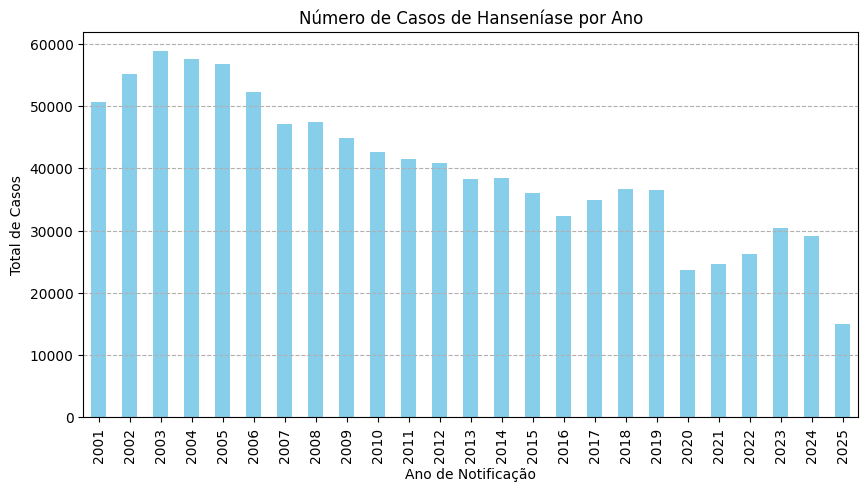

In [34]:
# 1. Contagem de casos ao longo do tempo
contagem_anual = df_dados['NU_ANO'].value_counts().sort_index()

# 2. Visualização da série temporal
plt.figure(figsize=(10, 5))
contagem_anual.plot(kind='bar', color='skyblue')
plt.title('Número de Casos de Hanseníase por Ano')
plt.xlabel('Ano de Notificação')
plt.ylabel('Total de Casos')
plt.grid(axis='y', linestyle='--')
plt.show()

In [35]:
# Mapeamento para facilitar a leitura dos resultados
mapeamento_gif = {0: 'GIF 0', 1: 'GIF 1', 2: 'GIF 2', 3: 'Não Avaliado', 9: 'Ignorado'}
mapeamento_class = {1: 'Paucibacilar (PB)', 2: 'Multibacilar (MB)', 0: 'Não Classificado'}

# Distribuição da Classificação Operacional
print("Distribuição da Classificação Operacional:")
print(df_dados['CLASSATUAL_CAT'].map(mapeamento_class).value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Distribuição do Grau de Incapacidade Física (GIF)
print("\nDistribuição do Grau de Incapacidade no Diagnóstico:")
dist_gif = df_dados['AVAL_ATU_N_CAT'].map(mapeamento_gif).value_counts(normalize=True).mul(100).round(2)
print(dist_gif.astype(str) + '%')

# Correlação entre Classificação (MB) e Incapacidade (GIF2) - EDA Bivariada
# A proporção de GIF2 dentro do grupo MB é um indicador importante
df_bivariada = df_dados.groupby('CLASSATUAL_CAT')['AVAL_ATU_N_CAT'].value_counts(normalize=True).mul(100).unstack()
print("\nProporção de GIF por Classificação (MB/PB):")
print(df_bivariada.rename(columns=mapeamento_gif, index=mapeamento_class).round(2))

Distribuição da Classificação Operacional:
CLASSATUAL_CAT
Multibacilar (MB)    66.31%
Paucibacilar (PB)    33.42%
Não Classificado      0.27%
Name: proportion, dtype: object

Distribuição do Grau de Incapacidade no Diagnóstico:
AVAL_ATU_N_CAT
GIF 0           40.81%
Ignorado        29.01%
Não Avaliado    16.93%
GIF 1            9.72%
GIF 2            3.53%
Name: proportion, dtype: object

Proporção de GIF por Classificação (MB/PB):
AVAL_ATU_N_CAT     GIF 0  GIF 1  GIF 2  Não Avaliado  Ignorado
CLASSATUAL_CAT                                                
Não Classificado    9.07   1.66   0.53         21.76     66.98
Paucibacilar (PB)  52.75   4.53   0.90         20.09     21.73
Multibacilar (MB)  34.92  12.37   4.87         15.32     32.53


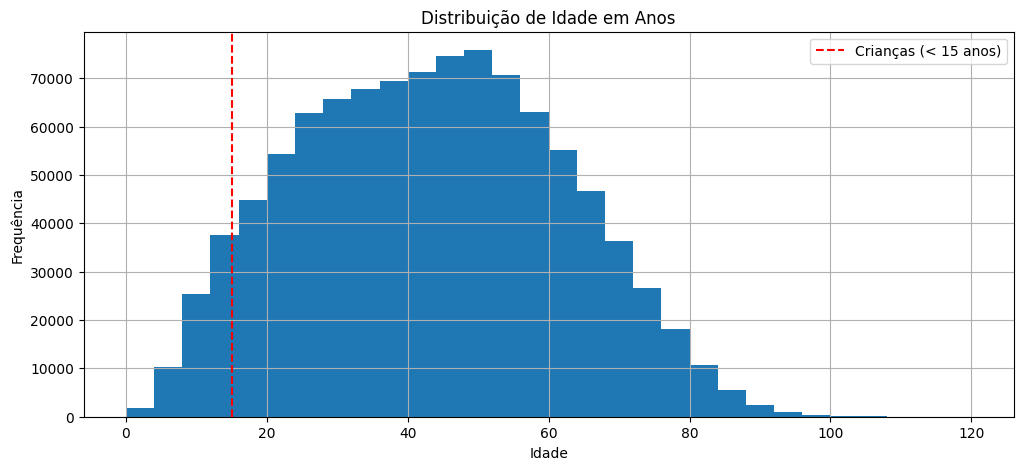


Percentual de Valores Faltantes/NaN em Colunas Chave:
CLASSATUAL_CAT    0.0
AVAL_ATU_N_CAT    0.0
CS_SEXO_CAT       0.0
CS_RACA_CAT       0.0
NU_LESOES_CAT     0.0
dtype: float64


In [36]:
# 1. Distribuição da Idade (Foco em transmissão ativa e envelhecimento)
plt.figure(figsize=(12, 5))
df_dados['IDADE_ANOS'].hist(bins=30)
plt.title('Distribuição de Idade em Anos')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.axvline(x=15, color='r', linestyle='--', label='Crianças (< 15 anos)')
plt.legend()
plt.show()

# 2. Análise de Missing Data/Ignorados
# (Apenas para colunas relevantes que não foram completamente tratadas ou dropadas)
colunas_principais = ['CLASSATUAL_CAT', 'AVAL_ATU_N_CAT', 'CS_SEXO_CAT', 'CS_RACA_CAT', 'NU_LESOES_CAT']
percentual_faltante = df_dados[colunas_principais].isnull().sum() / len(df_dados) * 100
print("\nPercentual de Valores Faltantes/NaN em Colunas Chave:")
print(percentual_faltante.sort_values(ascending=False))

## 1. Preparação e Análise das Variáveis-Alvo
O Grau de Incapacidade Física (GIF) é uma medida que indica a perda de sensibilidade protetora e/ou deformidade visível resultante de lesão neural. O GIF é avaliado tanto no momento do diagnóstico (AVALIA_N) quanto na alta por cura (AVAL_ATU_N).

### 1.1 Limpeza e Distribuição da Variável-Alvo (AVAL_ATU_N_CAT)
A variável AVAL_ATU_N possui as categorias 3 (Não avaliado) e 9 (Ignorado). Como o objetivo é prever o resultado clínico da incapacidade (0, 1 ou 2), é comum remover ou tratar estas categorias, pois representam falhas na avaliação ou dados ausentes.

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Total de registros para modelagem (GIF 0, 1 ou 2): 539572

Distribuição da Incapacidade Física na Alta (AVAL_ATU_N_CAT):
AVAL_ATU_N_CAT
0    75.49%
1    17.98%
2     6.53%
Name: proportion, dtype: object


C:\Users\Aureziano\AppData\Local\Temp\ipykernel_9932\1280553542.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df_model, palette='viridis')


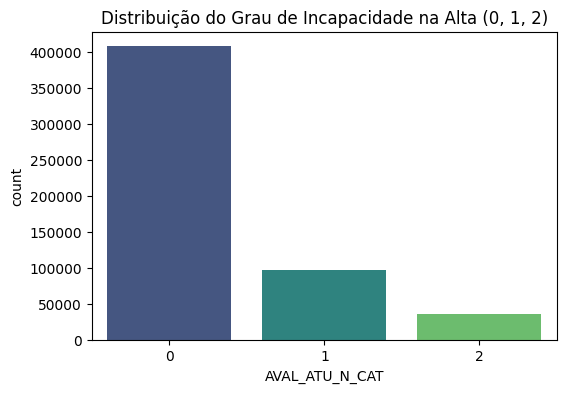

In [38]:
# ---------------------------------------------------------
# ETAPA 1: Preparação da Variável-Alvo
# ---------------------------------------------------------

# Filtrar o DataFrame para remover as categorias 'Não avaliado' (3) e 'Ignorado' (9)
# Assumindo que a variável AVAL_ATU_N_CAT já foi criada (código 504)

df_model = df_dados.copy()
target_col = 'AVAL_ATU_N_CAT'

# Focar apenas nos casos onde a avaliação na alta foi realmente realizada (GIF 0, 1 ou 2)
df_model = df_model[df_model[target_col].isin([0,1,2])]

print(f"Total de registros para modelagem (GIF 0, 1 ou 2): {len(df_model)}")

# Distribuição da Variável-Alvo
print("\nDistribuição da Incapacidade Física na Alta (AVAL_ATU_N_CAT):")
dist_final = df_model[target_col].value_counts(normalize=True).sort_index().mul(100).round(2)
print(dist_final.astype(str) + '%')

plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df_model, palette='viridis')
plt.title('Distribuição do Grau de Incapacidade na Alta (0, 1, 2)')
plt.show()

### 1.2 Análise da Progressão da Incapacidade
O fator mais importante para prever a incapacidade final (AVAL_ATU_N) é, geralmente, a incapacidade inicial (AVALIA_N). A Avaliação Neurológica Simplificada (ANS) é realizada no diagnóstico e na alta, e seus resultados são comparados.


Distribuição do Grau de Incapacidade no Diagnóstico (AVALIA_N_CAT):
AVALIA_N_CAT
Grau 0     67.54%
Grau I     24.44%
Grau II     8.02%
Name: proportion, dtype: object

Matriz de Transição GIF (Diagnóstico -> Alta - % por linha):
AVAL_ATU_N_CAT  Grau 0  Grau I  Grau II
AVALIA_N_CAT                           
Grau 0           91.92    6.81     1.27
Grau I           46.36   48.40     5.24
Grau II          25.92   19.83    54.24


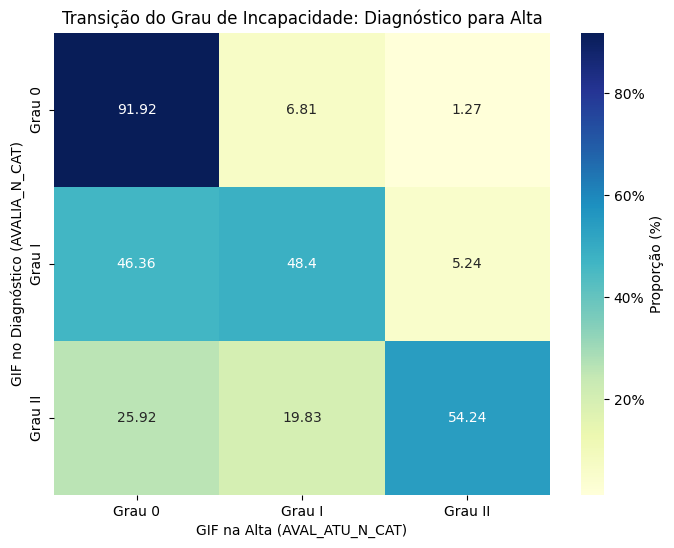

In [39]:
# Mapeamento para legendas claras
gif_map = {0: 'Grau 0', 1: 'Grau I', 2: 'Grau II'}

# Distribuição da Incapacidade no Diagnóstico (AVALIA_N_CAT)
print("\nDistribuição do Grau de Incapacidade no Diagnóstico (AVALIA_N_CAT):")
dist_initial = df_model['AVALIA_N_CAT'].map(gif_map).value_counts(normalize=True).mul(100).round(2)
print(dist_initial.astype(str) + '%')

# Tabela de Contingência (Progressão GIF: Início vs. Fim)
# Esta é a análise detalhada da relação entre as duas variáveis centrais
contingency_table = pd.crosstab(
    df_model['AVALIA_N_CAT'].map(gif_map),
    df_model['AVAL_ATU_N_CAT'].map(gif_map),
    normalize='index' # Normaliza por linha para ver a probabilidade de transição
).mul(100).round(2)

print("\nMatriz de Transição GIF (Diagnóstico -> Alta - % por linha):")
print(contingency_table)

plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, fmt='g', cmap='YlGnBu',
            cbar_kws={'format': '%.0f%%', 'label': 'Proporção (%)'})
plt.title('Transição do Grau de Incapacidade: Diagnóstico para Alta')
plt.ylabel('GIF no Diagnóstico (AVALIA_N_CAT)')
plt.xlabel('GIF na Alta (AVAL_ATU_N_CAT)')
plt.show()

Insight: Espera-se que a maioria dos pacientes (especialmente aqueles que começaram com GIF 0 ou GIF 1) mantenha ou melhore o GIF na alta (gif de 0), mas a proporção de GIF 2 na alta, especialmente em quem começou com GIF 0 ou GIF 1, indica piora da função neural ou detecção de deficiências pré-existentes na avaliação final

## 2. Segmentação Temporal e Definição de Features
O estudo deve ser construído até o início da pandemia (final de 2019) para análise posterior (2020+). O dataset deve ser dividido em treino (pré-pandemia) e teste/validação (pós-pandemia).

### 2.1 Engenharia de Features Temporais
As variáveis de data (DT_DIAG, DTALTA_N) são importantes para calcular o tempo de tratamento, o que pode estar relacionado à morbidade e ao risco de reações hansênicas.

In [40]:
# ---------------------------------------------------------
# ETAPA 2.1: Engenharia de Features de Tempo
# ---------------------------------------------------------

# Converter colunas de data (assumindo formato padronizado após pré-processamento)
df_model['DT_DIAG'] = pd.to_datetime(df_model['DT_DIAG'], errors='coerce')
df_model['DTALTA_N'] = pd.to_datetime(df_model['DTALTA_N'], errors='coerce')

# Calcular Duração do Tratamento em Dias
df_model['DURACAO_TRATAMENTO_DIAS'] = (df_model['DTALTA_N'] - df_model['DT_DIAG']).dt.days

# Calcular o Ano de Notificação/Diagnóstico (essencial para o split)
df_model['ANO_DIAGNOSTICO'] = df_model['DT_DIAG'].dt.year

# Tratar NaN em duração, substituindo por 0 (ou imputação estratégica se for a maioria)
df_model['DURACAO_TRATAMENTO_DIAS'] = df_model['DURACAO_TRATAMENTO_DIAS'].fillna(0)

In [41]:
# ---------------------------------------------------------
# ETAPA 2.2: Definição de Variáveis e Split Temporal
# ---------------------------------------------------------

# Variáveis (Features) a serem usadas na classificação
# Usamos as variáveis categóricas já tratadas (CAT) e numéricas cruciais (como idade)
features_base = [
    'AVALIA_N_CAT',      # GIF no Diagnóstico (Maior preditor do GIF final)
    'CLASSATUAL_CAT',    # Classificação Operacional (PB=1, MB=2) - MB tem maior risco de incapacidade [16, 17]
    'IDADE_ANOS',        # Idade (Maior idade é fator de risco para RAM e incapacidades) [16-18]
    'CS_SEXO_CAT',       # Sexo (Homens tem maior prevalência e risco de incapacidades) [16]
    'CS_RACA_CAT',       # Raça/Cor (Fator socioeconômico relevante) [1]
    'FORMACLINI_CAT',    # Forma Clínica (D/V são MB e mais incapacitantes) [16]
    'BACILOSCOP_CAT',    # Baciloscopia (Positiva implica MB e alta carga bacilar) [19, 20]
    'NERVOSAFET_CAT',    # Número de Nervos Afetados (Dano neural é a principal causa de incapacidade) [16, 21]
    'EPIS_RACIO_CAT',    # Episódios Reacionais (Grande causa de lesão neural e incapacidade) [16, 22, 23]
    'DOSE_RECEB_CAT',    # Doses Recebidas (Regime de tratamento)
    'DURACAO_TRATAMENTO_DIAS' # Tempo em tratamento
]

X = df_model[features_base]
Y = df_model[target_col]

# Separar dados de TREINO (Pré-pandemia) e TESTE (Pós-pandemia)
ANO_LIMITE_PANDEMIA = 2020 # Usar dados ANTES de 2020 para treino
X_train_pre = X[df_model['ANO_DIAGNOSTICO'] < ANO_LIMITE_PANDEMIA]
Y_train_pre = Y[df_model['ANO_DIAGNOSTICO'] < ANO_LIMITE_PANDEMIA]

X_test_post = X[df_model['ANO_DIAGNOSTICO'] >= ANO_LIMITE_PANDEMIA]
Y_test_post = Y[df_model['ANO_DIAGNOSTICO'] >= ANO_LIMITE_PANDEMIA]

print(f"\nConjunto de Treino (Pré-2020): {len(X_train_pre)} amostras")
print(f"Conjunto de Teste/Análise (Pós-2020): {len(X_test_post)} amostras")


Conjunto de Treino (Pré-2020): 488121 amostras
Conjunto de Teste/Análise (Pós-2020): 51451 amostras


Nota: Para a modelagem puramente preditiva (sem a restrição do estudo pós-pandemia), a literatura recomenda dividir os dados de treino e teste aleatoriamente (80/20 ou 90/10). No seu caso, o split temporal é um requisito metodológico essencial.

## 3. Seleção de Features e Redução de Dimensionalidade
O uso de técnicas de Seleção de Características (Feature Selection) é recomendado para determinar quais variáveis têm maior peso na predição. O Random Forest (RF) é um modelo robusto e interpretável que fornece a importância intrínseca de cada variável, sendo ideal para identificar as melhores features.

### 3.1 Pré-processamento e Encoding
As variáveis categóricas precisam ser transformadas (Encoded), e as numéricas padronizadas (Scaled), o que é feito eficientemente com ColumnTransformer e Pipeline.

In [47]:
# Definir colunas numéricas e categóricas
numerical_features = ['IDADE_ANOS', 'DURACAO_TRATAMENTO_DIAS']
categorical_features = [col for col in X.columns if col not in numerical_features]

# Criar o pré-processador (Escalonamento para numéricas e One-Hot Encoding para categóricas)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Ajustar e transformar os dados de treino (para obter os nomes das features transformadas)
X_train_processed = preprocessor.fit_transform(X_train_pre)
feature_names = preprocessor.get_feature_names_out()

# Acessar o número de colunas (features) com o índice [1]
print(f"\nDimensionalidade após One-Hot Encoding: {X_train_processed.shape[1]} features")


Dimensionalidade após One-Hot Encoding: 147 features


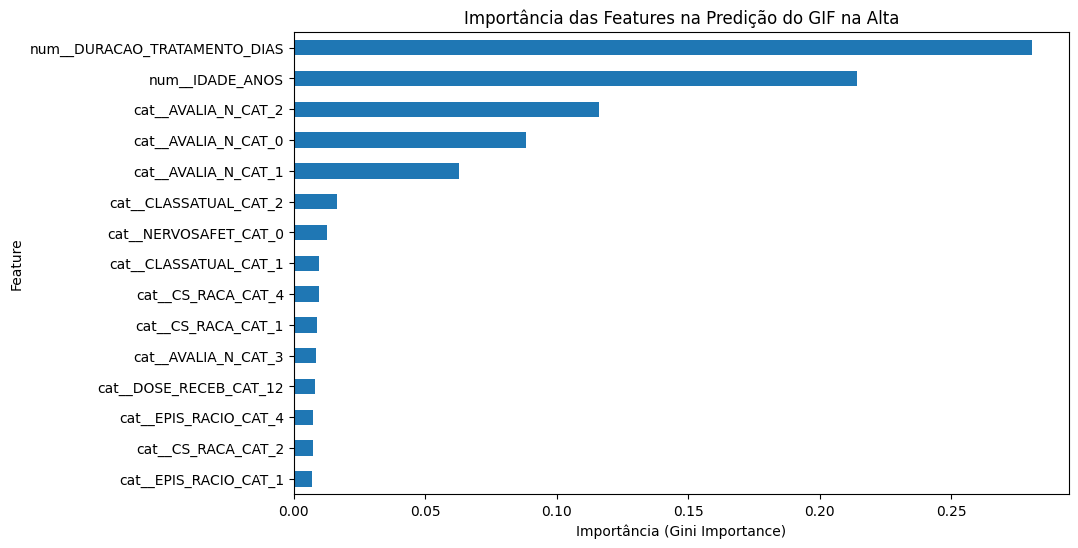

In [48]:
# ---------------------------------------------------------
# ETAPA 3.1: Análise de Importância das Features (Random Forest)
# ---------------------------------------------------------

# Treinar um modelo Random Forest (Regulador) para obter a importância das variáveis
# (Usamos o classificador pois a variável alvo é categórica 0, 1, 2)
rf_selector = RandomForestClassifier(n_estimators=20, random_state=42, class_weight='balanced', n_jobs=-1)
rf_selector.fit(X_train_processed, Y_train_pre)

# Extrair a importância das features
feature_importances = pd.Series(rf_selector.feature_importances_, index=feature_names)
feature_importances = feature_importances.sort_values(ascending=False)

# Visualizar as 15 features mais importantes
plt.figure(figsize=(10, 6))
feature_importances.head(15).plot(kind='barh')
plt.title('Importância das Features na Predição do GIF na Alta')
plt.ylabel('Feature')
plt.xlabel('Importância (Gini Importance)')
plt.gca().invert_yaxis()
plt.show()

# Seleção das features principais (e.g., as que juntas somam 95% da importância)
cummulative_importance = np.cumsum(feature_importances)
threshold_index = cummulative_importance[cummulative_importance < 0.95].index
selected_features_names = feature_importances.index.tolist() # Mantemos todas, mas a importância indica quais focar.

Nota sobre a importância das features: Em modelos preditivos para hanseníase, a literatura demonstra que as variáveis históricas (como a média móvel de casos) explicam a maior parte da capacidade preditiva (87% em um estudo). No modelo de classificação individual, é esperado que a AVALIA_N_CAT (GIF no diagnóstico) e as variáveis que indicam o estágio da doença (MB/PB, Baciloscopia, Nervos Afetados) sejam as mais importantes.

## 4. Criação e Treinamento do Modelo Preditivo
Vamos utilizar o Random Forest Classifier para a classificação multihíbrida (Grau 0, 1 ou 2). Embora GRUs (Gated Recurrent Units) sejam recomendadas para dados de séries temporais, o RF é mais simples de implementar e fornece insights de interpretabilidade imediata.

### 4.1 Pipeline de Modelagem

In [43]:
# ---------------------------------------------------------
# ETAPA 4.1: Treinamento do Modelo Final (Random Forest)
# ---------------------------------------------------------

# Usamos o pré-processador definido na etapa 3.1
# Criar o pipeline que inclui pré-processamento e o classificador
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', RandomForestClassifier(
                            n_estimators=200,          # Aumentar para melhor performance
                            max_depth=10,              # Limitar profundidade para evitar overfitting
                            random_state=42,
                            class_weight='balanced'    # Útil para lidar com desbalanço de classes (muito mais Grau 0)
                        ))])

# Treinar o modelo usando o conjunto de dados PRÉ-PANDEMIA
print("\nIniciando Treinamento do Modelo (Random Forest) com dados Pré-2020...")
model.fit(X_train_pre, Y_train_pre)
print("Treinamento concluído.")


Iniciando Treinamento do Modelo (Random Forest) com dados Pré-2020...
Treinamento concluído.


In [44]:
# ---------------------------------------------------------
# ETAPA 4.2: Avaliação no Conjunto de Teste Tradicional (Treino)
# ---------------------------------------------------------

# Para fins de verificação interna (opcional, mas recomendado)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_pre, Y_train_pre, test_size=0.2, random_state=42)
predictions_val = model.predict(X_val)
print("\nRelatório de Classificação no Conjunto de Validação (Interno Pré-2020):")
print(classification_report(Y_val, predictions_val))


Relatório de Classificação no Conjunto de Validação (Interno Pré-2020):
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     74610
           1       0.45      0.62      0.53     16809
           2       0.41      0.68      0.51      6206

    accuracy                           0.76     97625
   macro avg       0.59      0.70      0.63     97625
weighted avg       0.81      0.76      0.77     97625



## 5. Análise Pós-Pandemia (Impacto na Avaliação)
A etapa final utiliza o modelo treinado (pré-2020) para fazer previsões no período pós-pandemia (2020 e além). Isso permite analisar a disparidade entre a incapacidade predita pelo modelo histórico e a incapacidade realmente observada (Avaliada).


---------------------------------------------------------
Análise Pós-Pandemia (2020 e Posteriores)
---------------------------------------------------------
Métricas de Classificação (Predição de GIF na Alta):
              precision    recall  f1-score   support

      Grau 0       0.91      0.71      0.80     34382
      Grau I       0.52      0.70      0.60     12076
     Grau II       0.44      0.72      0.55      4993

    accuracy                           0.71     51451
   macro avg       0.62      0.71      0.65     51451
weighted avg       0.77      0.71      0.73     51451

Acurácia do Modelo Pré-2020 nos dados Pós-2020: 0.7116


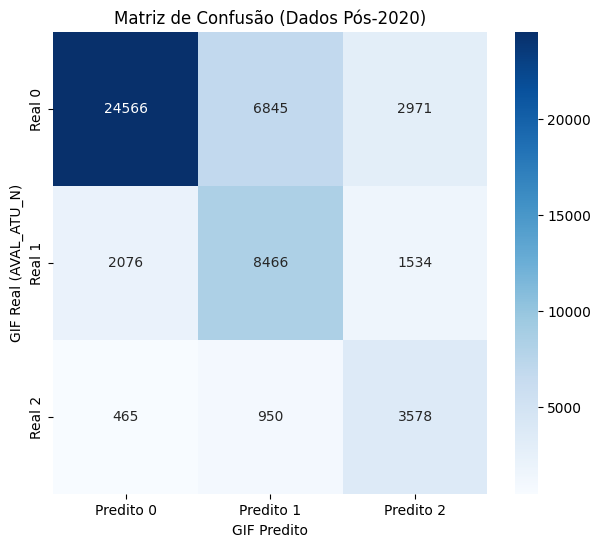

In [45]:
# ---------------------------------------------------------
# ETAPA 5: Predição e Avaliação no Período Pós-Pandemia (2020+)
# ---------------------------------------------------------

# Predição nos dados Pós-Pandemia
Y_pred_post = model.predict(X_test_post)

# Comparação: Incapacidade Observada vs. Incapacidade Predita
print("\n---------------------------------------------------------")
print("Análise Pós-Pandemia (2020 e Posteriores)")
print("---------------------------------------------------------")
print("Métricas de Classificação (Predição de GIF na Alta):")
print(classification_report(Y_test_post, Y_pred_post, target_names=['Grau 0', 'Grau I', 'Grau II']))

# Acurácia
accuracy = accuracy_score(Y_test_post, Y_pred_post)
print(f"Acurácia do Modelo Pré-2020 nos dados Pós-2020: {accuracy:.4f}")

# Visualizar a Matriz de Confusão (para ver onde o modelo erra)
cm = confusion_matrix(Y_test_post, Y_pred_post)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predito 0', 'Predito 1', 'Predito 2'],
            yticklabels=['Real 0', 'Real 1', 'Real 2'])
plt.title('Matriz de Confusão (Dados Pós-2020)')
plt.ylabel('GIF Real (AVAL_ATU_N)')
plt.xlabel('GIF Predito')
plt.show()

In [52]:
# ---------------------------------------------------------
# Insight Específico do Estudo
# ---------------------------------------------------------

# Adicionar a previsão ao conjunto de teste para análise
X_test_post['AVAL_ATU_N_REAL'] = Y_test_post
X_test_post['AVAL_ATU_N_PREDITO'] = Y_pred_post

# Calcular a diferença entre o GIF Real e o Predito
# Valores positivos (Real > Predito) indicam que a incapacidade real foi PIOR do que a histórica previa.
# Valores negativos (Real < Predito) indicam que a incapacidade real foi MELHOR do que a histórica previa.
X_test_post['DIFERENCA'] = X_test_post['AVAL_ATU_N_REAL'] - X_test_post['AVAL_ATU_N_PREDITO']

# Análise de Casos de Piora Inesperada (GIF Real é significativamente maior que o predito)
piora_inesperada = X_test_post[X_test_post['DIFERENCA'] > 0]
print(f"\nNúmero de casos onde a incapacidade real foi maior do que a predita (Piora): {len(piora_inesperada)}")

# Distribuição da incapacidade real vs. predita no período pós-pandemia
print("\nDistribuição da Incapacidade (GIF 2) Real vs. Predita no Pós-Pandemia:")
real_gif2_count = X_test_post[X_test_post['AVAL_ATU_N_REAL'] == 2].shape
pred_gif2_count = X_test_post[X_test_post['AVAL_ATU_N_PREDITO'] == 2].shape

print(f"GIF 2 Real (Observado): {real_gif2_count}")
print(f"GIF 2 Predito (Esperado pelo modelo pré-pandemia): {pred_gif2_count}")

# Calcular a taxa de detecção de GIF2 (indicador de detecção tardia [2]) no período pós-pandemia
# Ajuste para pegar o índice [0] se for uma tupla vinda de .shape
if isinstance(real_gif2_count, tuple):
    n_real = real_gif2_count[0]
else:
    n_real = real_gif2_count

if isinstance(pred_gif2_count, tuple):
    n_pred = pred_gif2_count[0]
else:
    n_pred = pred_gif2_count

taxa_gif2_real = n_real / len(X_test_post) * 100
taxa_gif2_predita = n_pred / len(X_test_post) * 100
print(f"Taxa de GIF 2 Real: {taxa_gif2_real:.2f}%")
print(f"Taxa de GIF 2 Predita: {taxa_gif2_predita:.2f}%")


Número de casos onde a incapacidade real foi maior do que a predita (Piora): 3491

Distribuição da Incapacidade (GIF 2) Real vs. Predita no Pós-Pandemia:
GIF 2 Real (Observado): (4993, 14)
GIF 2 Predito (Esperado pelo modelo pré-pandemia): (8083, 14)
Taxa de GIF 2 Real: 9.70%
Taxa de GIF 2 Predita: 15.71%


C:\Users\Aureziano\AppData\Local\Temp\ipykernel_9932\873707945.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_post['AVAL_ATU_N_REAL'] = Y_test_post
C:\Users\Aureziano\AppData\Local\Temp\ipykernel_9932\873707945.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_post['AVAL_ATU_N_PREDITO'] = Y_pred_post
C:\Users\Aureziano\AppData\Local\Temp\ipykernel_9932\873707945.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

In [51]:
# Instalar bibliotecas necessárias se não tiver
# !pip install imbalanced-learn xgboost

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# 1. Aplicar SMOTE no treino
print("Aplicando SMOTE para balanceamento...")
smote = SMOTE(random_state=42)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train_processed, Y_train_pre)

# 2. Treinar XGBoost
print("Treinando XGBoost...")
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
model_xgb.fit(X_train_resampled, Y_train_resampled)

# 3. Avaliar
Y_pred_xgb = model_xgb.predict(preprocessor.transform(X_test_post)) # Note que transformamos o teste com o preprocessor original
print("\nRelatório XGBoost + SMOTE (Pós-Pandemia):")
print(classification_report(Y_test_post, Y_pred_xgb))

Aplicando SMOTE para balanceamento...
Treinando XGBoost...

Relatório XGBoost + SMOTE (Pós-Pandemia):
              precision    recall  f1-score   support

           0       0.88      0.76      0.82     34382
           1       0.52      0.70      0.59     12076
           2       0.58      0.65      0.61      4993

    accuracy                           0.74     51451
   macro avg       0.66      0.70      0.67     51451
weighted avg       0.77      0.74      0.75     51451



In [58]:
from sklearn.feature_selection import RFE
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# 1. Seleção de Variáveis com RFE
print("Iniciando Seleção de Features com RFE...")
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rfe = RFE(estimator=rf_selector, n_features_to_select=10, step=1)
rfe.fit(X_train_pre, Y_train_pre)

# Identificar as colunas selecionadas
selected_features = [f for f, s in zip(X.columns, rfe.support_) if s]
print(f"Features Selecionadas: {selected_features}")

# --- CORREÇÃO AQUI: Filtrar o treino para usar apenas as features selecionadas ---
X_train_otimizado = X_train_pre[selected_features]
X_test_otimizado = X_test_post[selected_features]

# 2. Configuração do LightGBM e Otimização
print("\nOtimizando Hiperparâmetros do LightGBM...")
param_dist = {
    'n_estimators': [200, 400, 600],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 62, 127],
    'max_depth': [7, 10, 15, -1],
    'class_weight': ['balanced', None],
    'subsample': [0.7, 0.9, 1.0]
}

lgbm = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    lgbm, 
    param_distributions=param_dist, 
    n_iter=20, 
    scoring='recall_macro', 
    cv=tscv, 
    verbose=1, 
    random_state=42, 
    n_jobs=-1
)

# Treinar usando o dataset FILTRADO
random_search.fit(X_train_otimizado, Y_train_pre)

print(f"Melhores Parâmetros: {random_search.best_params_}")
best_model = random_search.best_estimator_

# 3. Avaliação no Teste (Também Filtrado)
Y_pred_lgbm = best_model.predict(X_test_otimizado)

print("\nRelatório Final (LightGBM Otimizado):")
print(classification_report(Y_test_post, Y_pred_lgbm))

Iniciando Seleção de Features com RFE...
Features Selecionadas: ['AVALIA_N_CAT', 'CLASSATUAL_CAT', 'IDADE_ANOS', 'CS_RACA_CAT', 'FORMACLINI_CAT', 'BACILOSCOP_CAT', 'NERVOSAFET_CAT', 'EPIS_RACIO_CAT', 'DOSE_RECEB_CAT', 'DURACAO_TRATAMENTO_DIAS']

Otimizando Hiperparâmetros do LightGBM...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Melhores Parâmetros: {'subsample': 0.9, 'num_leaves': 31, 'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.01, 'class_weight': 'balanced'}

Relatório Final (LightGBM Otimizado):
              precision    recall  f1-score   support

           0       0.91      0.70      0.79     34382
           1       0.51      0.72      0.59     12076
           2       0.45      0.71      0.55      4993

    accuracy                           0.71     51451
   macro avg       0.62      0.71      0.65     51451
weighted avg       0.77      0.71      0.72     51451



In [61]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from lightgbm import LGBMClassifier
from sklearn.metrics import make_scorer, recall_score, accuracy_score
import numpy as np

# 1. Divisão Inicial: Separa o "Mundo Normal" do "Mundo Pandêmico"
# Isso continua igual, pois precisamos dessa separação para a tese.
mask_pre = df_model['NU_ANO'] < 2020
X_historical = X[mask_pre]
Y_historical = Y[mask_pre]

X_pandemic = X[~mask_pre]
Y_pandemic = Y[~mask_pre]

# Filtrar colunas selecionadas pelo RFE (do passo anterior)
X_historical = X_historical[selected_features]
X_pandemic = X_pandemic[selected_features]

# 2. Definir a Validação Cruzada Temporal (Walk-Forward)
# Isso vai criar 5 dobras (splits) DENTRO dos dados históricos.
# Fold 1: Treina com dados antigos -> Valida em dados um pouco mais recentes
# Fold 2: Treina com dados antigos + recentes -> Valida em dados mais futuros...
tscv = TimeSeriesSplit(n_splits=5) 

# 3. Modelo e Hiperparâmetros
lgbm = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1, class_weight='balanced')

param_dist = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'max_depth': [5, 10, 15, -1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# 4. Otimização Robusta
# Usamos 'refit=True' para que, ao final, ele treine com TODOS os dados históricos (2001-2019)
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=20,
    scoring='recall_macro', # Foca em acertar todas as classes (especialmente a 2)
    cv=tscv, # AQUI ESTÁ O SEGREDO: Validação temporal, não aleatória
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("Iniciando Otimização com Time Series Cross-Validation...")
random_search.fit(X_historical, Y_historical)

print(f"\nMelhores Parâmetros: {random_search.best_params_}")
print(f"Melhor Score (Média da Validação): {random_search.best_score_:.4f}")

# 5. Teste Final no Cenário Pandêmico (Hold-out)
best_model = random_search.best_estimator_
Y_pred_pandemic = best_model.predict(X_pandemic)

print("\n--- PERFORMANCE NO CENÁRIO PANDÊMICO (2020-2025) ---")
print(classification_report(Y_pandemic, Y_pred_pandemic))

Iniciando Otimização com Time Series Cross-Validation...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores Parâmetros: {'subsample': 0.7, 'num_leaves': 31, 'n_estimators': 500, 'max_depth': 15, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Melhor Score (Média da Validação): 0.6945

--- PERFORMANCE NO CENÁRIO PANDÊMICO (2020-2025) ---
              precision    recall  f1-score   support

           0       0.91      0.70      0.79     35123
           1       0.51      0.72      0.59     12360
           2       0.45      0.71      0.55      5128

    accuracy                           0.70     52611
   macro avg       0.62      0.71      0.64     52611
weighted avg       0.77      0.70      0.72     52611



In [60]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.utils import class_weight
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- CORREÇÃO: Adaptação do Preprocessor para as Features Selecionadas ---

# 1. Identificar quais das features originais (num/cat) sobreviveram à seleção do RFE
# 'selected_features' é a lista que criamos no passo do LightGBM
sel_num_features = [col for col in numerical_features if col in selected_features]
sel_cat_features = [col for col in categorical_features if col in selected_features]

print(f"Features Numéricas usadas na GRU: {sel_num_features}")
print(f"Features Categóricas usadas na GRU: {sel_cat_features}")

# 2. Criar um NOVO preprocessor específico para esse subset de dados
# Importante: sparse_output=False para gerar matriz densa (necessário para Keras/Tensorflow)
preprocessor_dl = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), sel_num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), sel_cat_features)
    ],
    remainder='drop' # Garante que ignora qualquer outra coisa
)

# 3. Transformar os dados (Agora o fit é feito no dataset reduzido)
# X_train_otimizado e X_test_otimizado já foram criados no passo anterior
X_train_dl = preprocessor_dl.fit_transform(X_train_otimizado)
X_test_dl = preprocessor_dl.transform(X_test_otimizado)

# 4. Reshape para 3D [amostras, timesteps, features] -> Exigência da Camada GRU
# Como são dados tabulares (estáticos), usamos 1 timestep com N features
X_train_dl = X_train_dl.reshape((X_train_dl.shape[0], 1, X_train_dl.shape[1]))
X_test_dl = X_test_dl.reshape((X_test_dl.shape[0], 1, X_test_dl.shape[1]))

# 5. Preparação dos Targets (One-Hot Encoding para Multiclasse)
Y_train_enc = to_categorical(Y_train_pre)
Y_test_enc = to_categorical(Y_test_post)

# 6. Pesos das Classes (Balanceamento)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train_pre),
    y=Y_train_pre
)
class_weights = dict(enumerate(weights))

# --- Construção e Treinamento do Modelo ---

print("\nConstruindo modelo GRU...")
model_gru = Sequential()
# Input shape: (1, n_features)
model_gru.add(GRU(64, input_shape=(1, X_train_dl.shape[2]), return_sequences=False)) 
model_gru.add(Dropout(0.3)) 
model_gru.add(Dense(32, activation='relu'))
model_gru.add(Dense(3, activation='softmax')) # 3 classes (0, 1, 2)

model_gru.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model_gru.fit(
    X_train_dl, Y_train_enc,
    epochs=15, 
    batch_size=64,
    class_weight=class_weights,
    validation_split=0.1,
    verbose=1
)

# Avaliação
Y_pred_probs = model_gru.predict(X_test_dl)
Y_pred_gru = np.argmax(Y_pred_probs, axis=1)

print("\nRelatório Final (Deep Learning - GRU):")
print(classification_report(Y_test_post, Y_pred_gru))

Features Numéricas usadas na GRU: ['IDADE_ANOS', 'DURACAO_TRATAMENTO_DIAS']
Features Categóricas usadas na GRU: ['AVALIA_N_CAT', 'CLASSATUAL_CAT', 'CS_RACA_CAT', 'FORMACLINI_CAT', 'BACILOSCOP_CAT', 'NERVOSAFET_CAT', 'EPIS_RACIO_CAT', 'DOSE_RECEB_CAT']

Construindo modelo GRU...


d:\python\data_health\venv_health\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
6865/6865 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.7500 - loss: 0.7689 - val_accuracy: 0.7144 - val_loss: 0.8285
Epoch 2/15
6865/6865 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.7586 - loss: 0.7420 - val_accuracy: 0.7133 - val_loss: 0.8110
Epoch 3/15
6865/6865 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.7571 - loss: 0.7454 - val_accuracy: 0.7119 - val_loss: 0.8301
Epoch 4/15
6865/6865 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.7587 - loss: 0.7430 - val_accuracy: 0.7210 - val_loss: 0.7899
Epoch 5/15
6865/6865 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.7579 - loss: 0.7419 - val_accuracy: 0.7065 - val_loss: 0.8132
Epoch 6/15
6865/6865 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.7572 - loss: 0.7410 - val_accuracy: 0.7232 - val_loss: 0.7873
Epoch 7/15
6865/6865 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.7598 - loss: 0.7396 - val_accuracy: 0.7172 - val_loss: 0.7709
Epoch 8/15
6865/6865 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.7572 - loss: 0